# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Hernando, Claire Marie M.
- _Student No._: 2024-12904
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

**Plot for Part 1:** ![Plot of the Manual Evaluation (Bad Formula) vs. Rewritten Function (Good Formula) in Different Hardware Floating-Point Precisions (16/32/64/128-bit)"](../Claire/Exercise%202/Manual_vs._Rewritten_Plot_for_Part1.png)

**Plot for Part 2:** ![Plot of the Manual Evaluation (Bad Formula) vs. NumPy Special Function (Good Formula) in Different Hardware Floating-Point Precisions (16/32/64/128-bit)](../Claire/Exercise%202/Manual_vs._NumPy_Plot_for_Part2.png)

### Report discussion

1. In problem 1, since the value of b is extremely large relative to the coefficients a and c, the discriminant is approximately equal to b. When we apply the "bad" formula, we force the subtraction (different signs) of two nearly equal numbers, leading to catastrophic cancellation. This loses leading significant bits, and results to high relative error/noise. On the other hand, by applying the Vieta's Identity, we eliminate subtraction in the formula, as we now get numbers with the same sign, causing no cancellation, retaining all mantissa bits. This shows us that division in floating-point arithmetic does not result to loss of significance.

2. In problem 2, **part 1**, the catastrophic cancellation occurs for **large values of x** as $x \to \infty$, where $x^2 + x \approx x^2$. Here, the exact threshold depends on the precision, each having different breakdown points as shown in the graph. The expected value for this part is 0.5 since  $\lim_{x \to \infty} \left(\sqrt{x^2+x} - x\right) = 0.5$. This was remedied by conjugating the function, replacing the subtraction part with addition. For **part 2**, the catastrophic cancellation occurs for **very small values of x** as $x \to 0$, where $e^x \approx 1.0$, generating a 0.0. The expected value for this part is 1.0 since  $\lim_{x \to 0} \frac{e^x - 1}{x} = 1.0$. This was remedied by using NumPy special function ('np.expm1'), evaluating $e^x - 1$ using Taylor series expansion. This eliminates the subtraction in the expression. 

### Other comments
This whole thing is new to me. I had to learn numbers in Python, as well as understand the basics of subtractive cancellation from the very start. I had to browse various sources to check how to make my code work, and verify with AI if I really answered the problem. I also went back and forth in debugging my codes.


## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
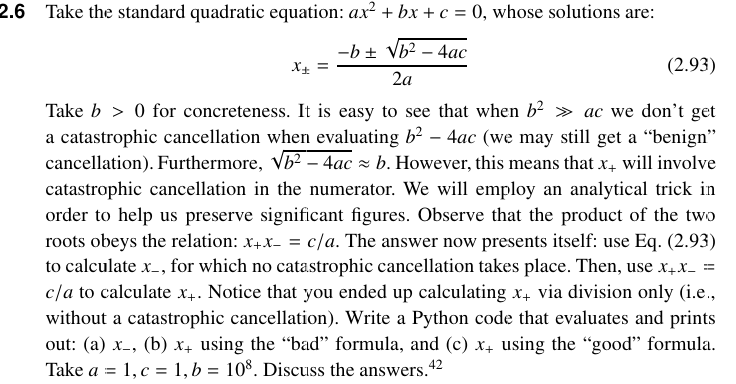

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Given coefficients
a = 1.0
b = 1e8 
c = 1.0

# Discriminant term in Eq 2.93
disc = math.sqrt(b**2 - 4*a*c)

# (a) x_ minus using standard formula
x_minus = (-b - disc) / (2*a)

# (b) x_ plus using the "bad" formula (causes catastrophic cancellation)
x_plus_bad = (-b + disc) / (2*a)

# (c) x_ plus using the "good" formula (by Vieta's Identity; no catastrophic cancellation) 
x_plus_good = c / (a * x_minus)

print(f"(a) x_minus (standard formula) : {x_minus:.16e}") # Based on the 64-bit double-precision arithmetic (IEEE 754)
print(f"(b) x_plus (bad formula)      : {x_plus_bad:.16e}")
print(f"(c) x_plus (good formula)     : {x_plus_good:.16e}")

(a) x_minus (standard formula) : -1.0000000000000000e+08
(b) x_plus (bad formula)      : -7.4505805969238281e-09
(c) x_plus (good formula)     : -1.0000000000000000e-08


#### Problem 1 code summary

This script shows how to avoid catastrophic cancellation in double-precision floating-point arithmetic when solving quadratic equations with b² >> ac, where b > 0. Here, the x_- and x_+ are calculated, taking into consideration the catastrophic cancellation in x_+. 

First, this script computes the numerically stable root (x_minus) using the standard formula. Then, this shows how catastrophic cancellation happens in x_+ when we merely subtract nearly equal numbers, given that disc ≈ b. To avoid such, we then make use of the relation of the roots in Vieta's identity, $x_+ = \frac{c}{ax_-}$, to calculate x_+ via division rather than subtracting the two nearly equal numbers. 

The printed outputs are formatted based on the full 64-bit IEEE 754 precision limit through `:.16e`, further highlighting how subtraction destroys accuracy while division preserves it.


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur? 
- How can we rewrite the function to avoid catastrophic cancellation? 
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

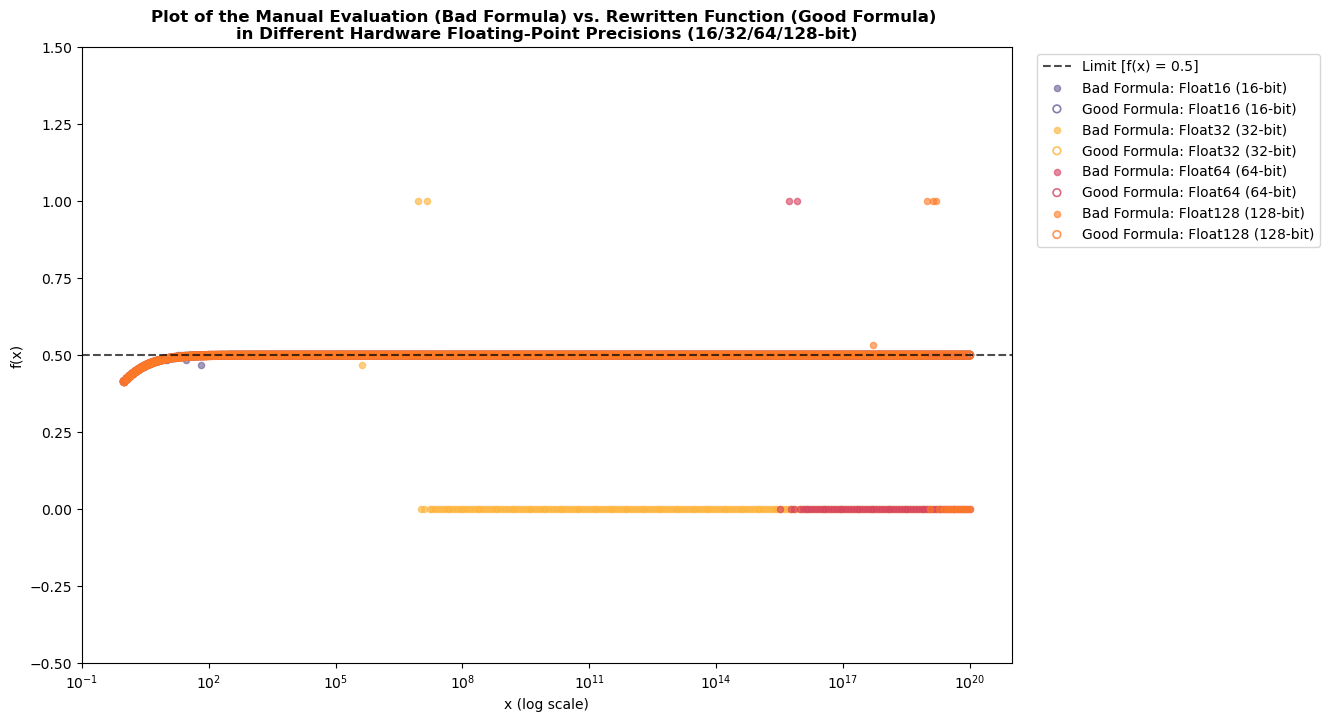

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values across a log scale (10^0 to 10^20)
x = np.logspace(0, 20, 300)

# Comparison of the 4 precisions (16/32/64/128-bit), and their colors, and scatter markers 
precisions = [
    ("Float16 (16-bit)", np.float16, "#6b5b95", "o"),
    ("Float32 (32-bit)", np.float32, "#feb236", "o"),
    ("Float64 (64-bit)", np.float64, "#d64161", "o"),
    ("Float128 (128-bit)", np.float128, "#ff7b25", "o"),
]

# Figure size
plt.figure(figsize=(12, 8))

# Horizontal limit reference line at f(x) = 0.5
plt.axhline(0.5, color="black", linestyle="--", alpha=0.7, label="Limit [f(x) = 0.5]")

# Compute and plot scatter points using pure plt functions
for label, dtype, color, marker in precisions:
    # This is to ignore overflow warnings for np.float16 at very high x values
    with np.errstate(over='ignore', invalid='ignore'):
        x_cast = x.astype(dtype)
        
        # Bad Formula (causes catastrophic cancellation)
        y_bad = np.sqrt(x_cast**2 + x_cast) - x_cast
        
        # Good Formula (By conjugation, and replacing subtraction with addition)
        y_good = 1.0 / (np.sqrt(1.0 + 1.0 / x_cast) + 1.0) 

    # Solid Markers for Bad Formula 
    plt.scatter(x, y_bad, color=color, alpha=0.6, s=20, marker=marker, label=f"Bad Formula: {label}")
    
    # Hollow Markers for Good Formula
    plt.scatter(x, y_good, facecolors="none", edgecolors=color, alpha=0.8, s=30, marker=marker, linewidths=1.2, label=f"Good Formula: {label}")

# Styling plot using pure plt functions
plt.xscale("log")
plt.ylim(-0.5, 1.5)
plt.xlabel("x (log scale)")
plt.ylabel("f(x)")
plt.title(
    "Plot of the Manual Evaluation (Bad Formula) vs. Rewritten Function (Good Formula) \nin Different Hardware Floating-Point Precisions (16/32/64/128-bit)",
    fontsize=12,
    fontweight="bold"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)

plt.savefig("Manual_vs._Rewritten.png", dpi=300, bbox_inches="tight")
plt.show()

## With Highlights of the Region Where the Cancellation Occurs

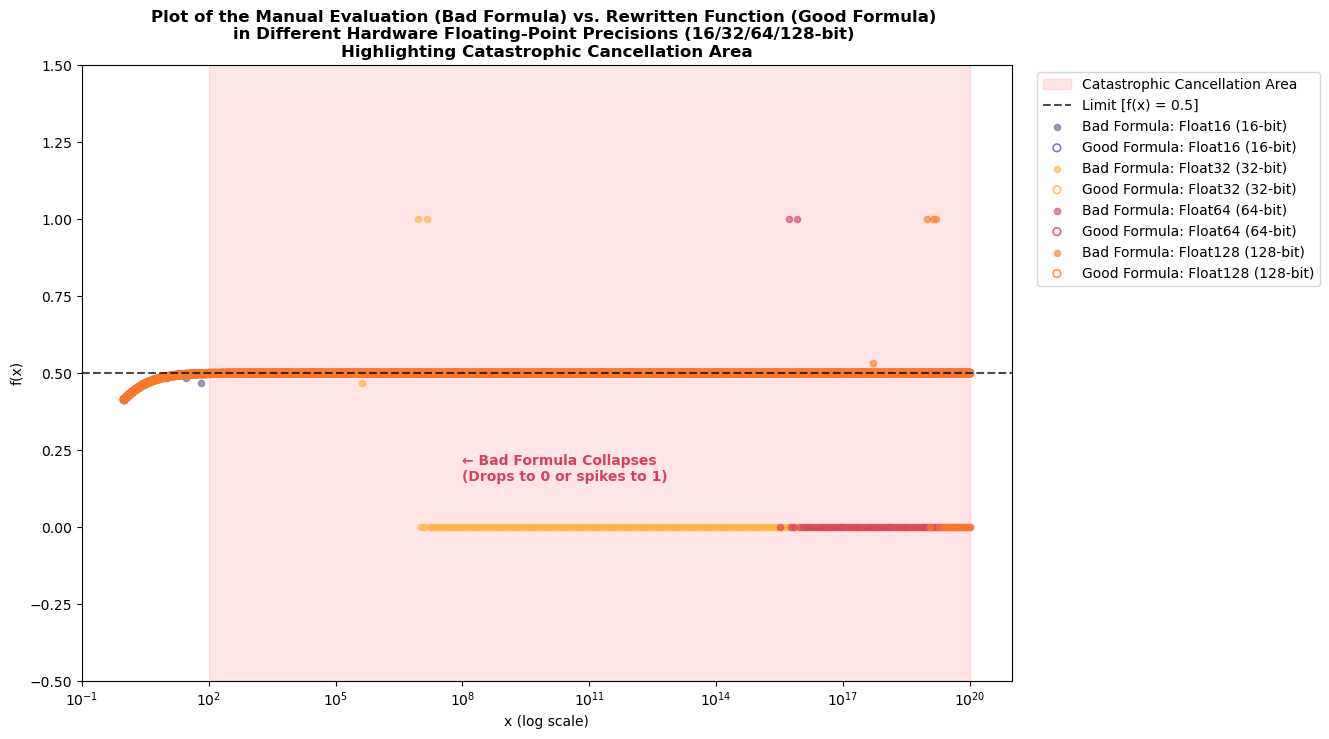

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values across a log scale (10^0 to 10^20)
x = np.logspace(0, 20, 300)

# Comparison of the 4 precisions (16/32/64/128-bit), and their colors, and scatter markers 
precisions = [
    ("Float16 (16-bit)", np.float16, "#6b5b95", "o"),
    ("Float32 (32-bit)", np.float32, "#feb236", "o"),
    ("Float64 (64-bit)", np.float64, "#d64161", "o"),
    ("Float128 (128-bit)", np.float128, "#ff7b25", "o"),
]

# Figure size
plt.figure(figsize=(12, 8))

# Highlighting the region where the cancellation occurs
plt.axvspan(10**2, 10**20, color="red", alpha=0.1, label="Catastrophic Cancellation Area")

# Horizontal limit reference line at f(x) = 0.5
plt.axhline(0.5, color="black", linestyle="--", alpha=0.7, label="Limit [f(x) = 0.5]")

# Compute and plot scatter points using pure plt functions
for label, dtype, color, marker in precisions:
    # This is to ignore overflow warnings for np.float16 at very high x values
    with np.errstate(over='ignore', invalid='ignore'):
        x_cast = x.astype(dtype)
        
        # Bad Formula (causes catastrophic cancellation)
        y_bad = np.sqrt(x_cast**2 + x_cast) - x_cast
        
        # Good Formula (By conjugation, and replacing subtraction with addition)
        y_good = 1.0 / (np.sqrt(1.0 + 1.0 / x_cast) + 1.0) 

    # Solid Markers for Bad Formula 
    plt.scatter(x, y_bad, color=color, alpha=0.6, s=20, marker=marker, label=f"Bad Formula: {label}")
    
    # Hollow Markers for Good Formula
    plt.scatter(x, y_good, facecolors="none", edgecolors=color, alpha=0.8, s=30, marker=marker, linewidths=1.2, label=f"Good Formula: {label}")

# Labelling breakdown points in the cancellation region
plt.text(10**8, 0.15, "← Bad Formula Collapses\n(Drops to 0 or spikes to 1)", color="#d64161", fontsize=10, fontweight="bold")

# Styling plot using pure plt functions
plt.xscale("log")
plt.ylim(-0.5, 1.5)
plt.xlabel("x (log scale)")
plt.ylabel("f(x)")
plt.title(
    "Plot of the Manual Evaluation (Bad Formula) vs. Rewritten Function (Good Formula) \nin Different Hardware Floating-Point Precisions (16/32/64/128-bit) \nHighlighting Catastrophic Cancellation Area",
    fontsize=12,
    fontweight="bold"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(False)

plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur? 
- How can we resolve the catastrophic cancellation? 
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



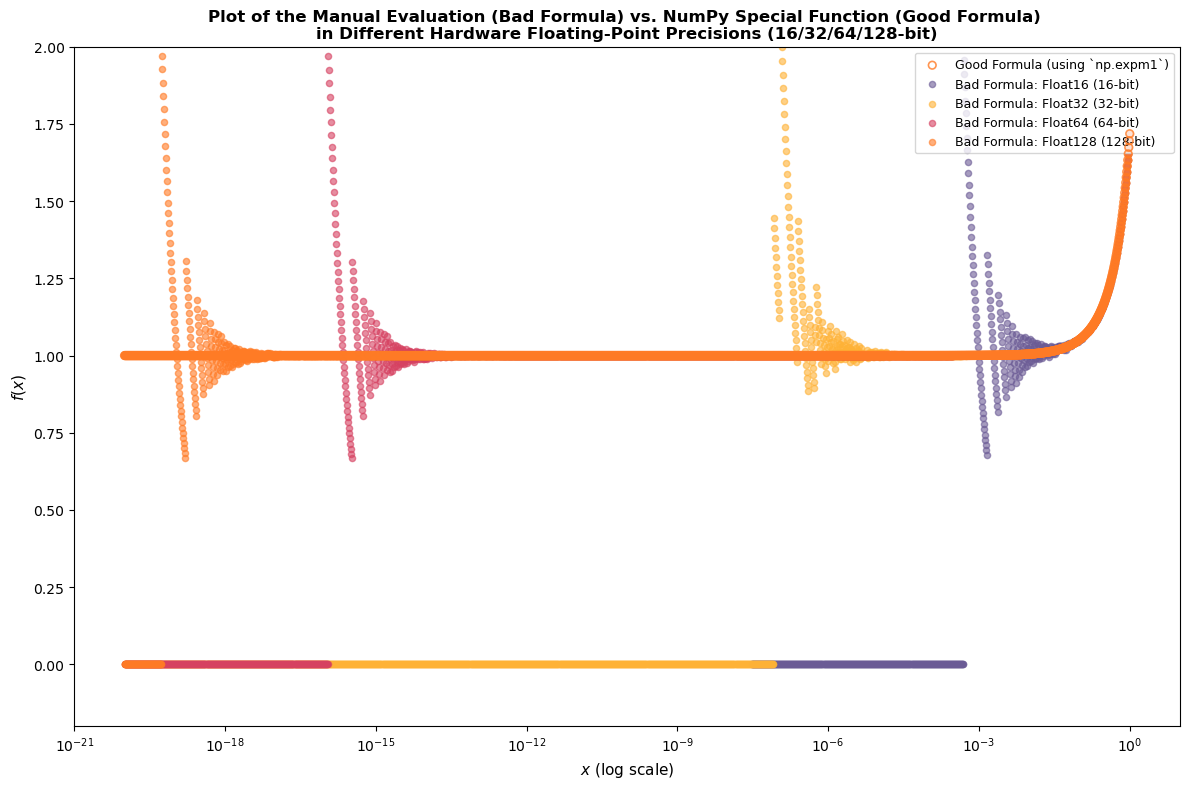

In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values across a log scale (10^0 down to 10^-20)
x_base = np.logspace(-20, 0, 2000)

# Figure size
plt.figure(figsize=(12, 8))

# Good Formula (in NumPy Special Function)
f_good = np.expm1(x_base) / x_base # This function computes e^x - 1
plt.scatter(x_base, f_good, facecolors="none", edgecolors=color, alpha=0.8, s=30, marker=marker, linewidths=1.2, label='Good Formula (using `np.expm1`)', zorder=10)

# Evaluating Bad Formula across precisions: (e^x - 1) / x
precisions = [
    ('Float16 (16-bit)', np.float16, '#6b5b95'),
    ('Float32 (32-bit)', np.float32, '#feb236'),
    ('Float64 (64-bit)', np.float64, '#d64161'),
]

# Check for 128-bit float support since it might crash if not supported
if hasattr(np, 'float128'):
    precisions.append(('Float128 (128-bit)', np.float128, '#ff7b25'))
elif hasattr(np, 'longdouble'):
    precisions.append(('Extended Precision', np.longdouble, '#ff7b25'))

# Setting up Bad Formula (causes Catastrophic Cancellation)
for label, dtype, color in precisions:
    x = x_base.astype(dtype)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_bad = (np.exp(x) - 1) / x 
    plt.scatter(x_base, f_bad, label=f"Bad Formula: {label}", color=color, alpha=0.6, s=20, marker=marker,)

# Styling plot using pure plt functions
plt.xscale('log')
plt.ylim(-0.2, 2)
plt.xlabel('$x$ (log scale)', fontsize=11)
plt.ylabel('$f(x)$', fontsize=11)
plt.title(
    "Plot of the Manual Evaluation (Bad Formula) vs. NumPy Special Function (Good Formula) \nin Different Hardware Floating-Point Precisions (16/32/64/128-bit)",
    fontsize=12,
    fontweight="bold"
)
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

plt.tight_layout()

plt.savefig("Manual_vs._NumPy_Plot_for_Part2.png", dpi=300, bbox_inches="tight") # This is how we save the image below under our working folder.
plt.show()

## With Highlights of the Region Where the Cancellation Occurs

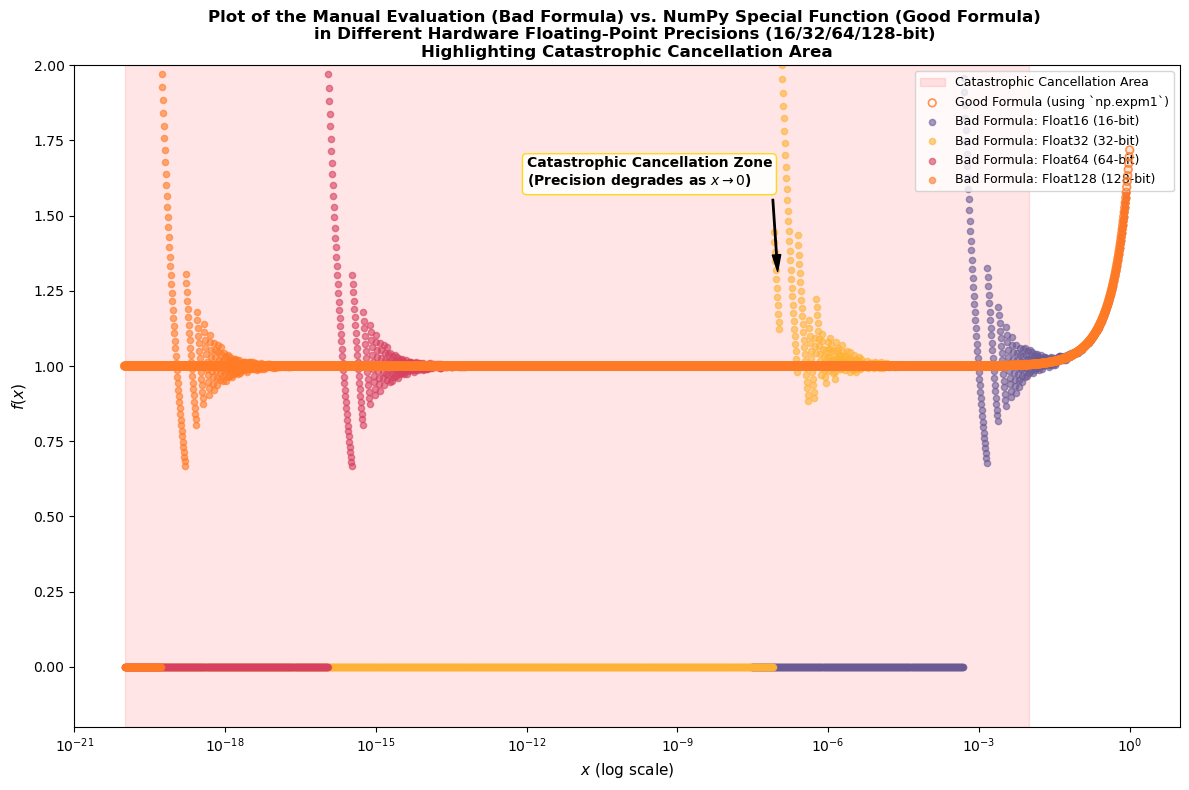

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values across a log scale (10^0 down to 10^-20)
x_base = np.logspace(-20, 0, 2000)

# Figure size
plt.figure(figsize=(12, 8))

# Highlighting the region where the cancellation occurs
plt.axvspan(1e-20, 1e-2, color="red", alpha=0.1, label="Catastrophic Cancellation Area")

# Labelling cancellation region
plt.annotate(
    'Catastrophic Cancellation Zone\n(Precision degrades as $x \\to 0$)',
    xy=(1e-7, 1.3),
    xytext=(1e-12, 1.6),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gold', alpha=0.9)
)

# Good Formula (in NumPy Special Function)
f_good = np.expm1(x_base) / x_base # This function computes e^x - 1
plt.scatter(x_base, f_good, facecolors="none", edgecolors=color, alpha=0.8, s=30, marker=marker, linewidths=1.2, label='Good Formula (using `np.expm1`)', zorder=10)

# Evaluating Bad Formula across precisions: (e^x - 1) / x
precisions = [
    ('Float16 (16-bit)', np.float16, '#6b5b95'),
    ('Float32 (32-bit)', np.float32, '#feb236'),
    ('Float64 (64-bit)', np.float64, '#d64161'),
]

# Check for 128-bit float support since it might crash if not supported
if hasattr(np, 'float128'):
    precisions.append(('Float128 (128-bit)', np.float128, '#ff7b25'))
elif hasattr(np, 'longdouble'):
    precisions.append(('Extended Precision', np.longdouble, '#ff7b25'))

# Setting up Bad Formula (causes Catastrophic Cancellation)
for label, dtype, color in precisions:
    x = x_base.astype(dtype)
    with np.errstate(divide='ignore', invalid='ignore'):
        f_bad = (np.exp(x) - 1) / x 
    plt.scatter(x_base, f_bad, label=f"Bad Formula: {label}", color=color, alpha=0.6, s=20, marker=marker,)
# Styling plot using pure plt functions
plt.xscale('log')
plt.ylim(-0.2, 2)
plt.xlabel('$x$ (log scale)', fontsize=11)
plt.ylabel('$f(x)$', fontsize=11)
plt.title(
    "Plot of the Manual Evaluation (Bad Formula) vs. NumPy Special Function (Good Formula) \nin Different Hardware Floating-Point Precisions (16/32/64/128-bit) \nHighlighting Catastrophic Cancellation Area",
    fontsize=12,
    fontweight="bold"
)
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

plt.tight_layout()
plt.show()

#### Problem 2 code summary

Both scripts show how we manipulate a function to avoid catastrophic cancellation. For part 1, since $x \to \infty$ would mean subtracting nearly equal large values, we resolved the cancellation by algebraically reformulating the expression, replacing subtraction by addition. For part 2, since $x \to 0$ would cause the given function to a precision loss, we used NumPy's specialized function (np.expm1), resulting to subtraction-free polynomial approximations. Both scripts show that assessing the formula across different precisions temporarily addresses the catastrophe, whereas manipulating them algebraically fixes the problem. 

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2)) # Mas malaking percent error

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
